# Pulsed Laser Beam Waist Analysis
Knife-edge measurements to determine beam waist profile along the propagation axis.

In [22]:
%matplotlib inline
import importlib
import pulsed_laser_waist
importlib.reload(pulsed_laser_waist)
from pulsed_laser_waist import (
    read_knife_edge_by_z,
    fit_erf_anchored,
    waist_vs_z,
)
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


## Parameters — edit these before running

In [23]:
folder = "F:/Lab data/20260401"

# Minimum samples between detected peaks
min_peak_distance = 50

# Minimum peak prominence (None = auto: 5% of signal range)
min_peak_prominence = None

# Set True to plot raw trace + peaks for every file
plot_peaks = False

# Endpoint samples used to anchor ERF asymptotes
n_flat = 2

# Laser wavelength in metres (Nd:YAG 1064 nm)
wavelength = 1.064e-6


## Step 1 — Read CSV files grouped by z position

In [24]:
z_data = read_knife_edge_by_z(
    folder,
    min_peak_distance=min_peak_distance,
    min_peak_prominence=min_peak_prominence,
    plot=plot_peaks,
)


z = 0 mm  (step = 15×0.001" = 381.0 µm)  |  7 x positions
z = 1 mm  (step = 10×0.001" = 254.0 µm)  |  8 x positions
z = 2 mm  (step = 10×0.001" = 254.0 µm)  |  8 x positions
z = 3 mm  (step = 5×0.001" = 127.0 µm)  |  13 x positions
z = 4 mm  (step = 10×0.001" = 254.0 µm)  |  7 x positions
z = 5 mm  (step = 5×0.001" = 127.0 µm)  |  10 x positions
z = 6 mm  (step = 5×0.001" = 127.0 µm)  |  11 x positions
z = 7 mm  (step = 5×0.001" = 127.0 µm)  |  8 x positions
z = 8 mm  (step = 2×0.001" = 50.8 µm)  |  10 x positions


## Step 2 — ERF fit for each z position

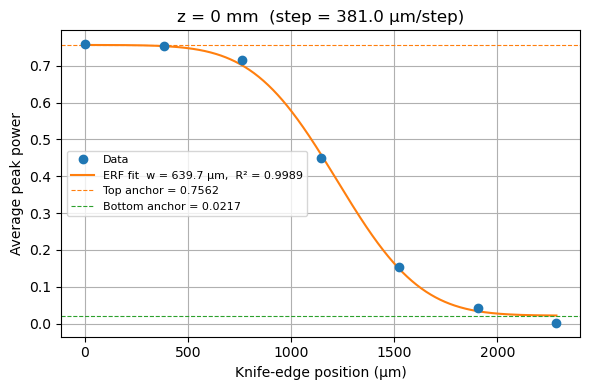

z = 0 mm  |  w = 639.72 µm  |  R² = 0.99887


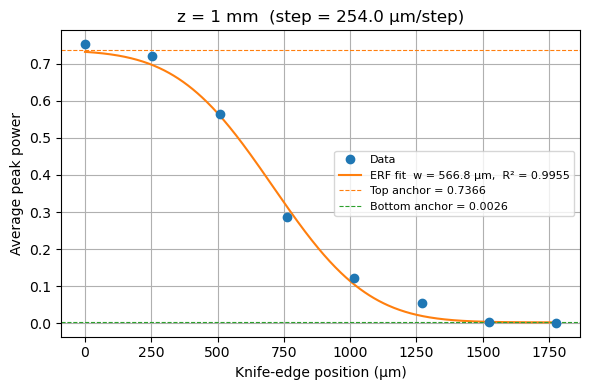

z = 1 mm  |  w = 566.85 µm  |  R² = 0.99545


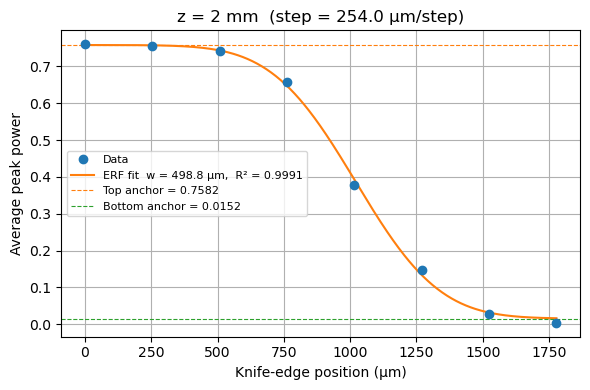

z = 2 mm  |  w = 498.85 µm  |  R² = 0.99912


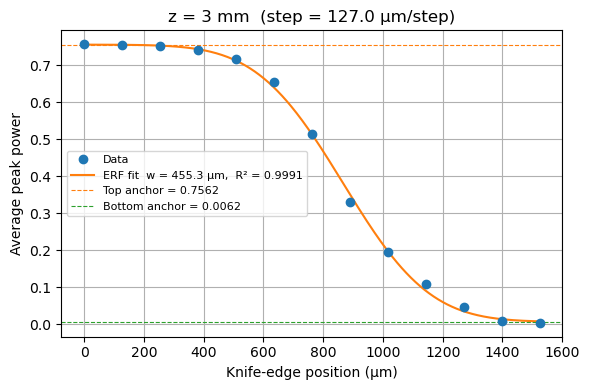

z = 3 mm  |  w = 455.30 µm  |  R² = 0.99905


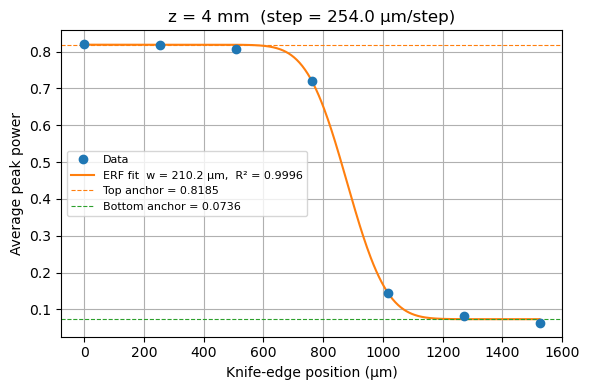

z = 4 mm  |  w = 210.24 µm  |  R² = 0.99960


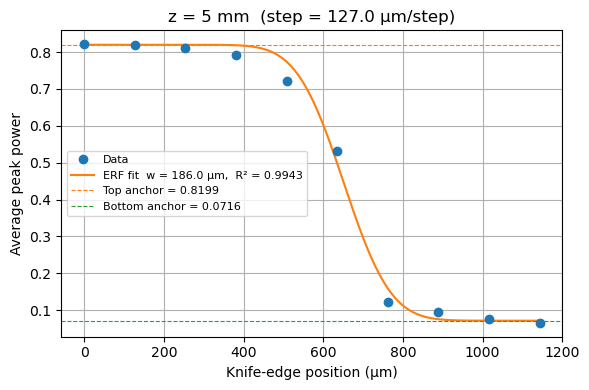

z = 5 mm  |  w = 186.02 µm  |  R² = 0.99426


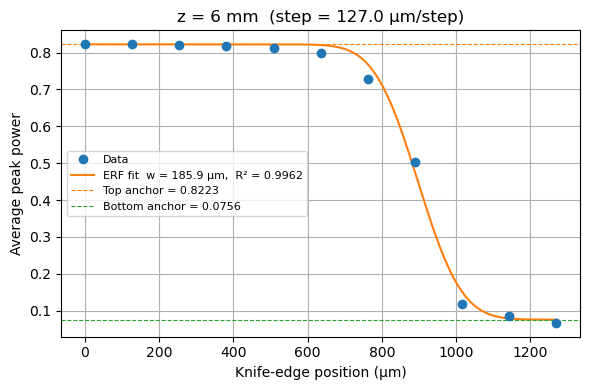

z = 6 mm  |  w = 185.91 µm  |  R² = 0.99618


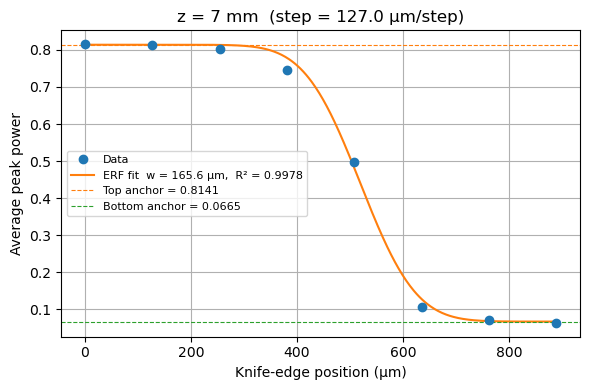

z = 7 mm  |  w = 165.62 µm  |  R² = 0.99783


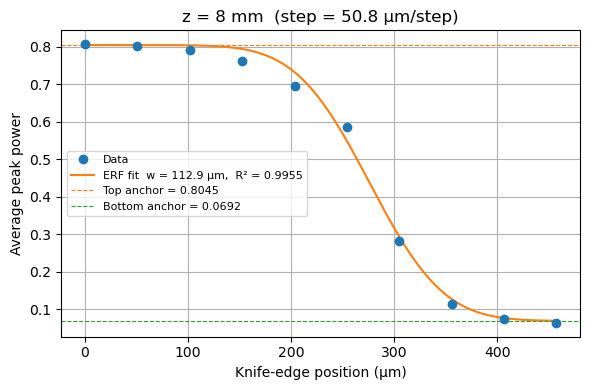

z = 8 mm  |  w = 112.86 µm  |  R² = 0.99549


In [25]:
z_mm_list = []
waist_um_list = []

for z_mm, info in z_data.items():
    x = info["x_um"]
    y = info["avg_power"]

    x0_fit, w_fit, y_top, y_bottom, r2, model_fn = fit_erf_anchored(x, y, n_flat=n_flat)

    z_mm_list.append(z_mm)
    waist_um_list.append(w_fit)

    x_fine = np.linspace(x.min(), x.max(), 500)
    y_fit_curve = model_fn(x_fine)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y, "o", label="Data", zorder=5)
    ax.plot(x_fine, y_fit_curve,
            label=f"ERF fit  w = {w_fit:.1f} µm,  R² = {r2:.4f}")
    ax.axhline(y_top,    color="C1", linestyle="--", linewidth=0.8,
               label=f"Top anchor = {y_top:.4f}")
    ax.axhline(y_bottom, color="C2", linestyle="--", linewidth=0.8,
               label=f"Bottom anchor = {y_bottom:.4f}")
    ax.set_xlabel("Knife-edge position (µm)")
    ax.set_ylabel("Average peak power")
    step_label = info["b"] * 25.4
    ax.set_title(f"z = {z_mm} mm  (step = {step_label:.1f} µm/step)")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"z = {z_mm} mm  |  w = {w_fit:.2f} µm  |  R² = {r2:.5f}")


## Step 3 — Beam waist profile vs z

Focus position z0 = 8.79 mm
Beam waist    w0  = 4.83 µm
R²               = 0.90476


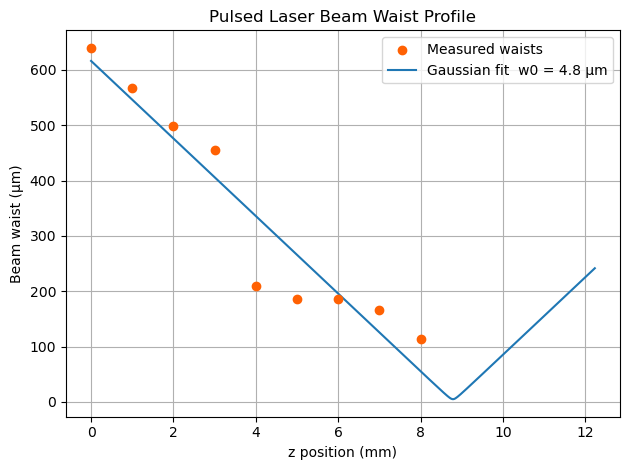

In [30]:
z_arr = np.array(z_mm_list, dtype=float) * 1e-3   # mm -> m
w_arr = np.array(waist_um_list, dtype=float) * 1e-6  # µm -> m

def model_fixed_lam(z, z0, w0):
    return waist_vs_z(z, z0, w0, lam=wavelength)

g0 = [z_arr.mean(), w_arr.min()]
popt, _ = curve_fit(model_fixed_lam, z_arr, w_arr, p0=g0)
z0_fit, w0_fit = popt

r2 = r2_score(w_arr, model_fixed_lam(z_arr, *popt))
print(f"Focus position z0 = {z0_fit*1e3:.2f} mm")
print(f"Beam waist    w0  = {w0_fit*1e6:.2f} µm")
print(f"R²               = {r2:.5f}")

# Extend plot range by one Rayleigh range beyond the data on each side
zr_fit = np.pi * w0_fit**2 / wavelength
z_plot_min = min(z_arr.min(), z0_fit)# - 50*zr_fit
z_plot_max = max(z_arr.max(), z0_fit) + 50*zr_fit
z_fine = np.linspace(z_plot_min, z_plot_max, 500)
w_fine = model_fixed_lam(z_fine, *popt)

fig, ax = plt.subplots()
ax.scatter(z_arr * 1e3, w_arr * 1e6, color="#FF6103", label="Measured waists", zorder=5)
ax.plot(z_fine * 1e3, w_fine * 1e6, label=f"Gaussian fit  w0 = {w0_fit*1e6:.1f} µm")
ax.set_xlabel("z position (mm)")
ax.set_ylabel("Beam waist (µm)")
ax.set_title("Pulsed Laser Beam Waist Profile")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Sphere position — ERF fit at fixed z

z = 0 mm  (step = 5×0.001" = 127.0 µm)  |  8 x positions


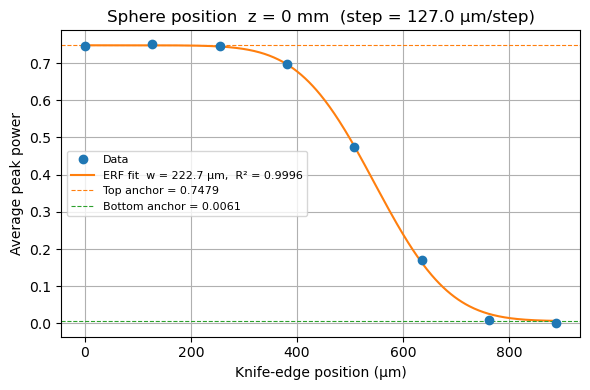

x0 = 546.11 µm
w  = 222.74 µm
R² = 0.99959


In [27]:
sphere_folder = "F:/Lab data/20260401/sphere position"

sp_data = read_knife_edge_by_z(
    sphere_folder,
    min_peak_distance=min_peak_distance,
    min_peak_prominence=min_peak_prominence,
)

# Only one z position in this folder
z_mm_sp, info_sp = next(iter(sp_data.items()))
x_sp = info_sp["x_um"]
y_sp = info_sp["avg_power"]

x0_sp, w_sp, y_top_sp, y_bottom_sp, r2_sp, model_sp = fit_erf_anchored(
    x_sp, y_sp, n_flat=n_flat)

x_fine_sp = np.linspace(x_sp.min(), x_sp.max(), 500)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_sp, y_sp, "o", label="Data", zorder=5)
ax.plot(x_fine_sp, model_sp(x_fine_sp),
        label=f"ERF fit  w = {w_sp:.1f} µm,  R² = {r2_sp:.4f}")
ax.axhline(y_top_sp,    color="C1", linestyle="--", linewidth=0.8,
           label=f"Top anchor = {y_top_sp:.4f}")
ax.axhline(y_bottom_sp, color="C2", linestyle="--", linewidth=0.8,
           label=f"Bottom anchor = {y_bottom_sp:.4f}")
ax.set_xlabel("Knife-edge position (µm)")
ax.set_ylabel("Average peak power")
step_label_sp = info_sp["b"] * 25.4
ax.set_title(f"Sphere position  z = {z_mm_sp} mm  (step = {step_label_sp:.1f} µm/step)")
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"x0 = {x0_sp:.2f} µm")
print(f"w  = {w_sp:.2f} µm")
print(f"R² = {r2_sp:.5f}")
